# Visualizations used for final project presentation

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from typing import Optional, Dict

from v1sh_model.inputs.visualize import visualize_input, visualize_output, plot_bars_colored
from v1sh_model.models.V1_model import V1_model

In [2]:
# Instantiate and test the FullModel
seed = 42
model = V1_model(seed=seed)
T = 12
dt = 0.05
I_input = 2.5

Use computed connections.


In [3]:
def orientation_singleton(x = 5, y = 5, N_x = 4, N_y = 2, I_input = 2.5, orientation = 0.0):
    A = np.full((N_y, N_x), orientation)
    A[y, x] = orientation + np.pi / 2
    C = np.full((N_y, N_x), I_input)
    return A, C

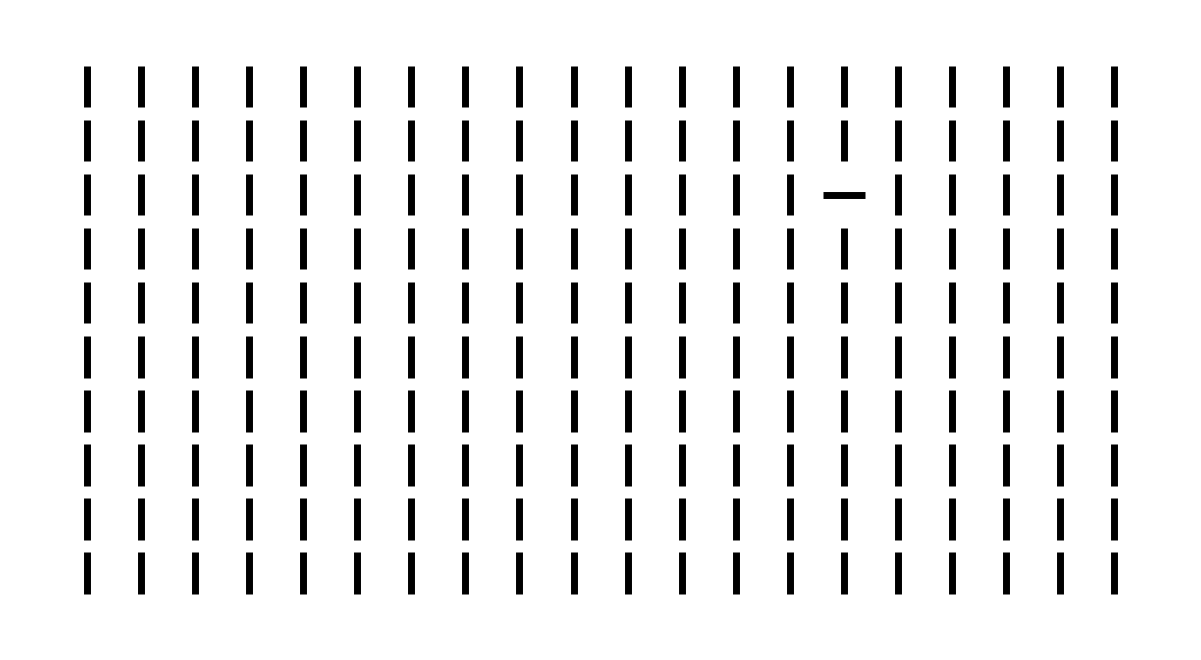

In [4]:
A, C = orientation_singleton(x = 14, y = 7, N_x=100, N_y=100, I_input=I_input, orientation = 0.00)
x_size, y_size = 20, 10
visualize_input(A[:y_size, :x_size], C[:y_size, :x_size], dpi = 600)
plt.show()

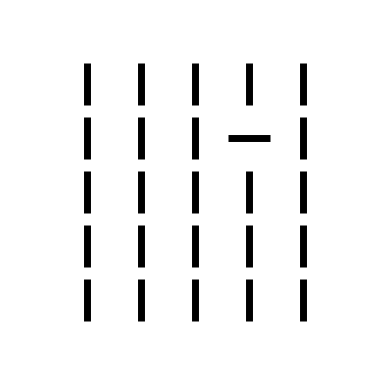

In [5]:
A, C = orientation_singleton(x = 3, y = 3, N_x=100, N_y=100, I_input=I_input, orientation = 0.00)
size = 5
visualize_input(A[:size, :size], C[:size, :size], dpi = 600)
plt.show()

In [6]:
X_gen, Y_gen, I = model.simulate(A, C, dt=dt, T=T, verbose=False, noisy=False, mode="wrap")
model_output = model.g_x(X_gen).mean(axis=0) # N_y x N_x x K

Simulating:   0%|          | 0/240 [00:00<?, ?step/s]

Simulating: 100%|██████████| 240/240 [00:42<00:00,  5.66step/s]


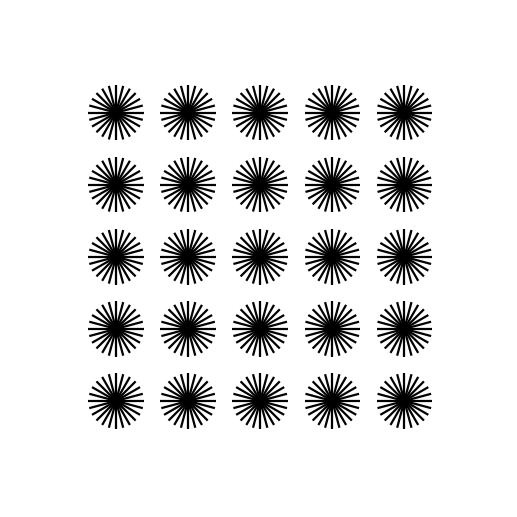

In [7]:
C_out = np.zeros_like(model_output) # model_output / model_output.mean()  # N_y x N_x
A_out = np.broadcast_to(model.M, C_out.shape)

visualize_output(A_out[:size, :size], C_out[:size, :size] + 0.2, verbose=False, dpi = 800)
plt.show()

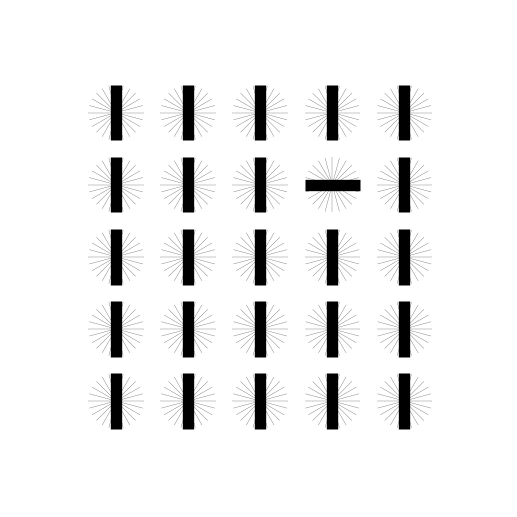

In [8]:
model_output = model.g_x(X_gen).mean(axis=0) # N_y x N_x x K

C_out = np.zeros_like(model_output) # model_output / model_output.mean()  # N_y x N_x
A_out = np.broadcast_to(model.M, C_out.shape)

N_y, N_x = A.shape
for k in range(model.K):
    for i in range(N_y):
        for j in range(N_x):
            if A[i, j] == k * np.pi / model.K:
                C_out[i, j, k] += 0.2 * C[i, j]

visualize_output(A_out[:size, :size], C_out[:size, :size] * 2 + 0.02, verbose=False, dpi = 800)
plt.show()

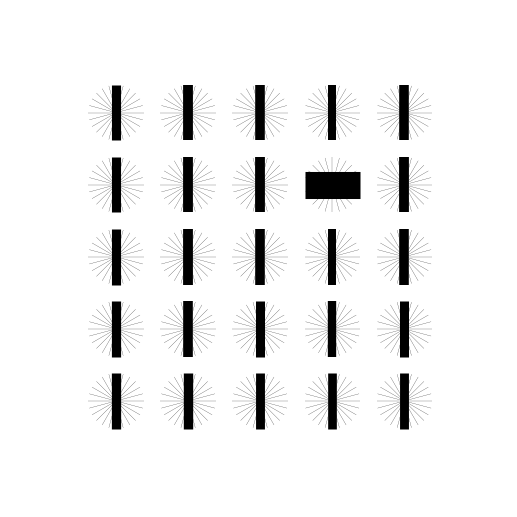

In [9]:
model_output = model.g_x(X_gen).mean(axis=0) # N_y x N_x x K
C_out = model_output / model_output.mean()  # N_y x N_x
A_out = np.broadcast_to(model.M, C_out.shape)
visualize_output(A_out[:size, :size], C_out[:size, :size] / 15 + 0.02, verbose=False, dpi = 800)
plt.show()

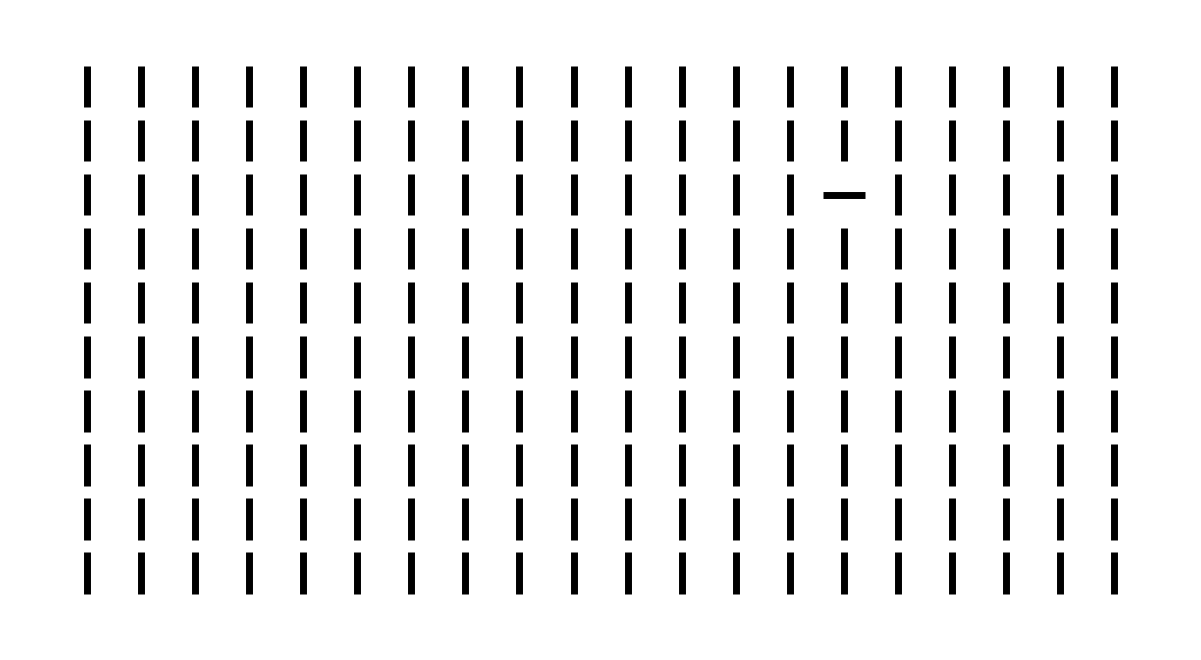

In [10]:
A, C = orientation_singleton(x = 14, y = 7, N_x=100, N_y=100, I_input=I_input, orientation = 0.00)
x_size, y_size = 20, 10
visualize_input(A[:y_size, :x_size], C[:y_size, :x_size], dpi = 600)
plt.show()

In [11]:
X_gen, Y_gen, I = model.simulate(A, C, dt=dt, T=T, verbose=False, noisy=False, mode="wrap")
model_output = model.g_x(X_gen).mean(axis=0) # N_y x N_x x K

Simulating: 100%|██████████| 240/240 [00:38<00:00,  6.23step/s]


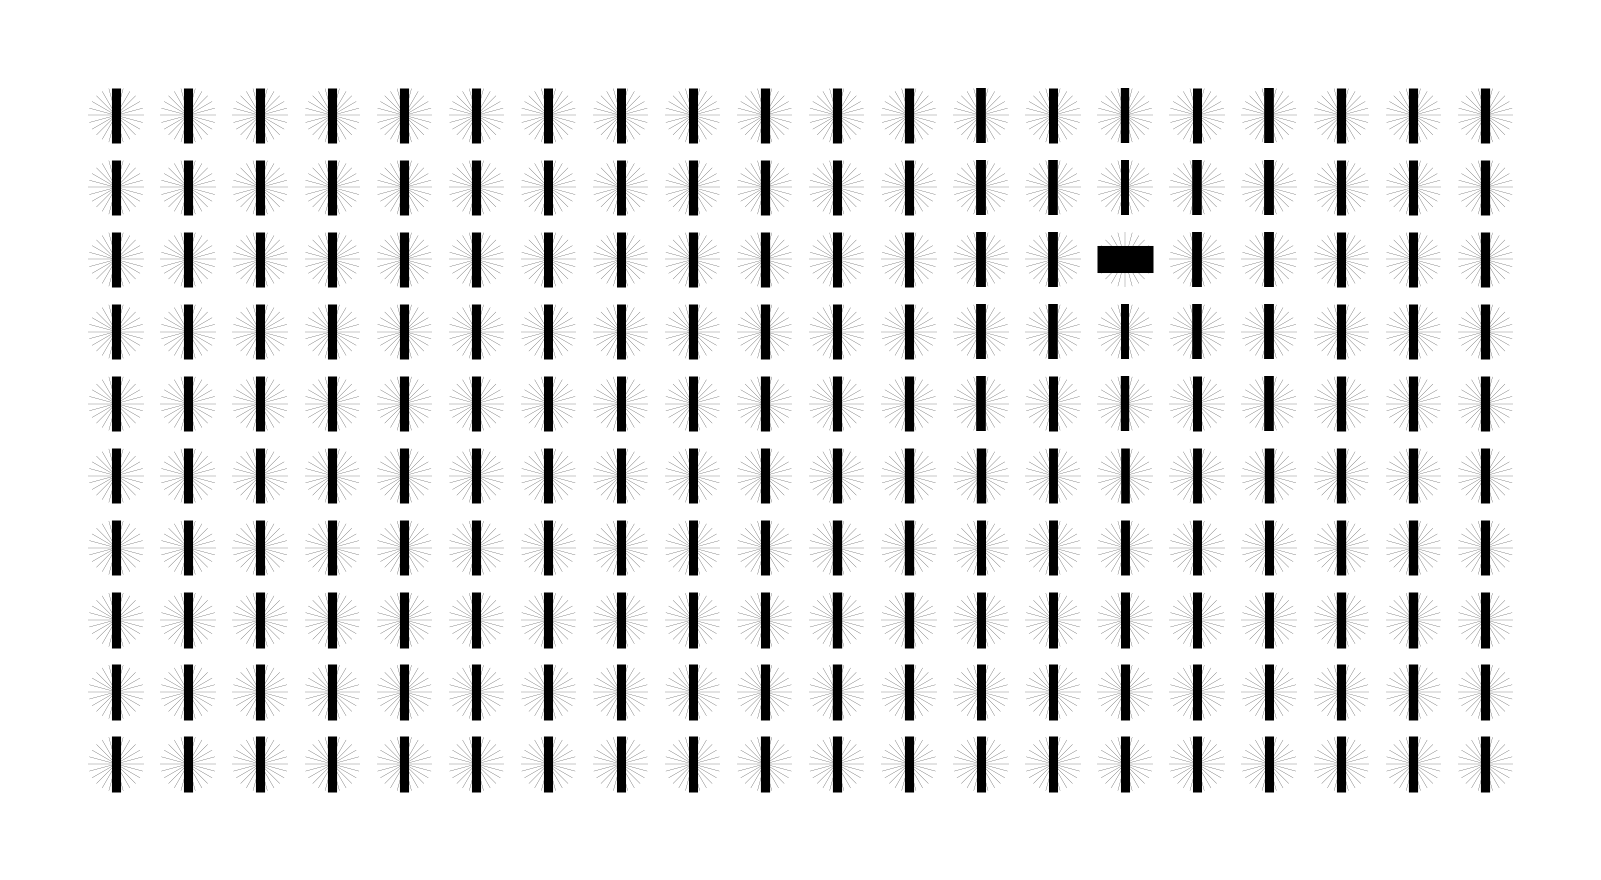

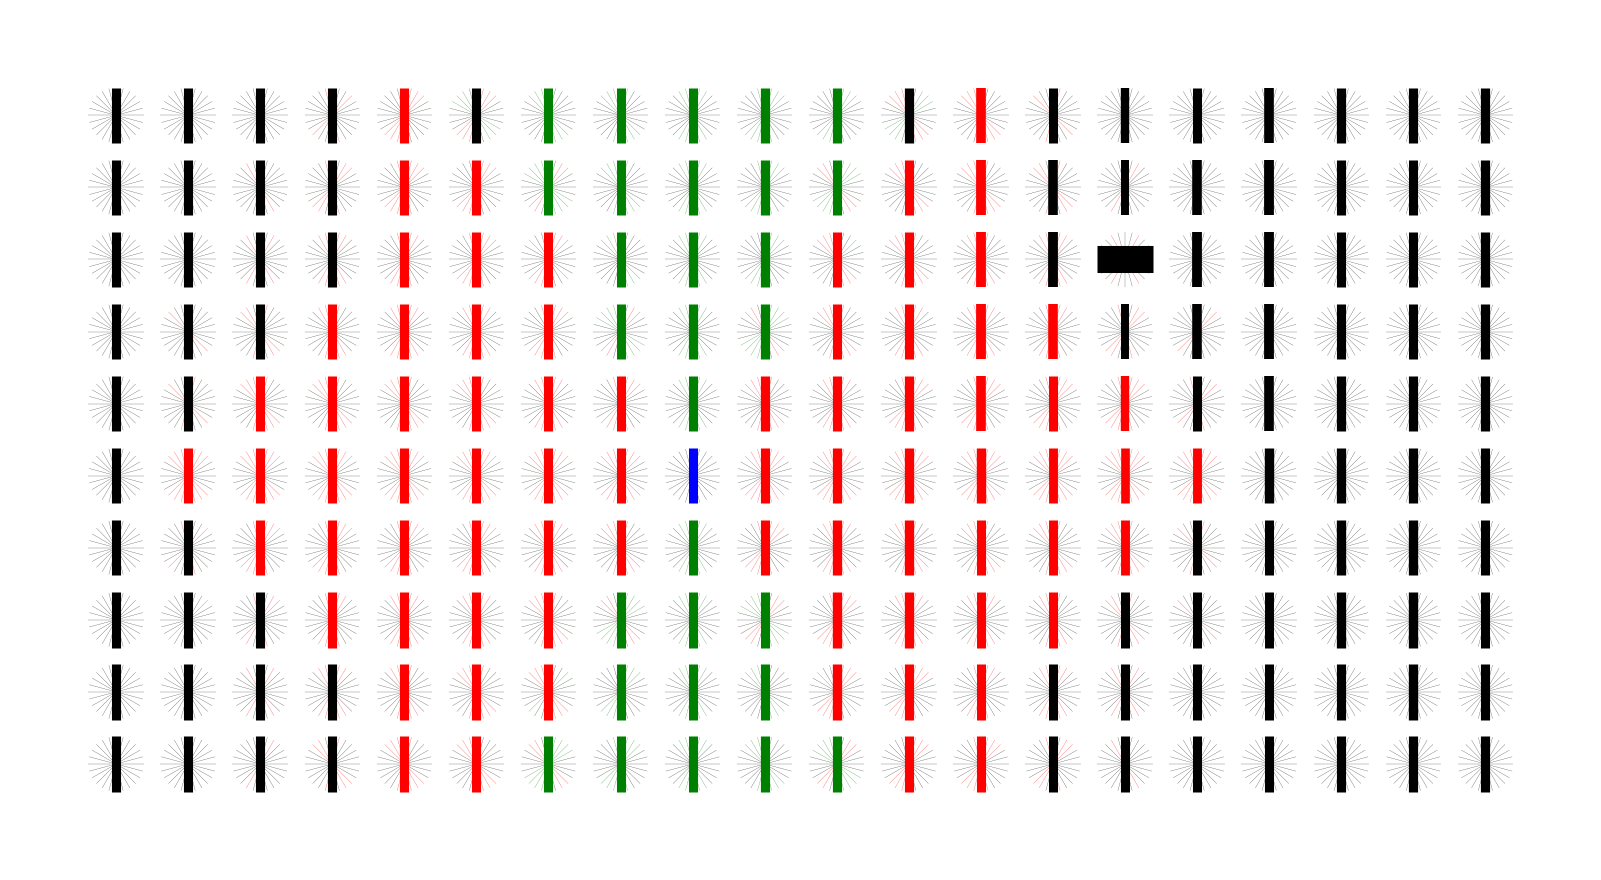

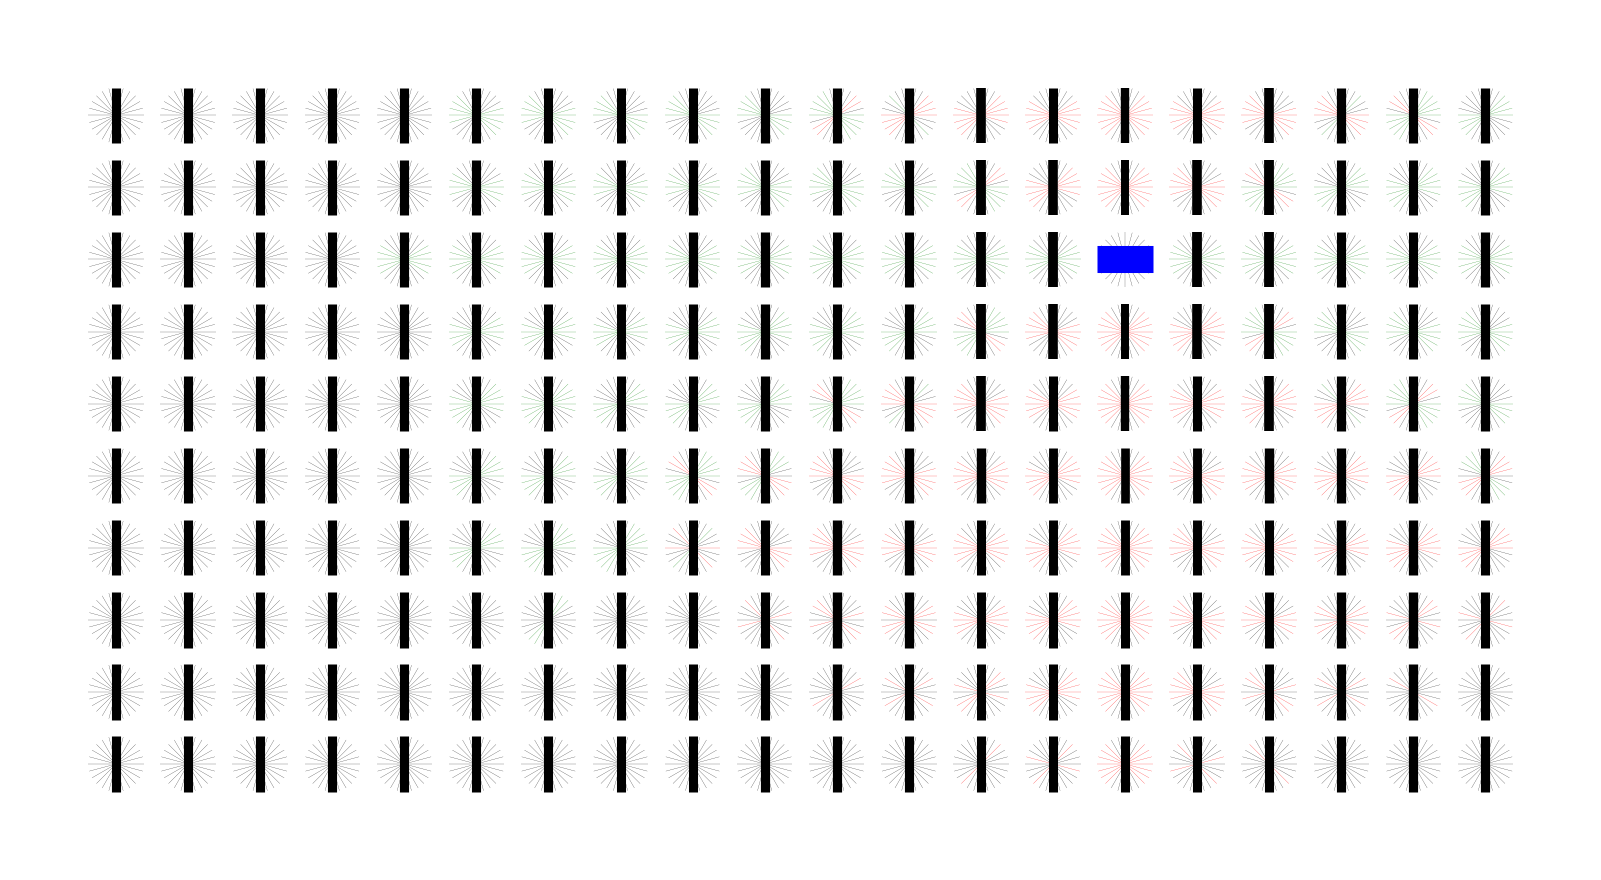

In [12]:
C_out = model_output / model_output.mean()  
A_out = np.broadcast_to(model.M, C_out.shape)
W, J = model.W, model.J
color_dict = {0: "black", 1: "red", 2: "green", 3: "blue"}

presynaptic_neuron_indices = [None, (4, 8, 0), (7, 14, 6)] # [(y, x, k), ...], None == no color map

for presynaptic_idx in presynaptic_neuron_indices:
    color_map = np.zeros_like(C_out, dtype=int)
    N_y, N_x, _ = color_map.shape
    
    # compute colormap
    if presynaptic_idx is not None:
        y_pre, x_pre, k_pre = presynaptic_idx
        y_min = max(0, y_pre - 10)
        y_max = min(N_y, y_pre + 11)
        x_min = max(0, x_pre - 10)
        x_max = min(N_x, x_pre + 11)
        color_map[y_min:y_max, x_min:x_max, :] += 1 * (W[10 - (y_pre - y_min):11 + (y_max - y_pre), 10 - (x_pre - x_min):11 + (x_max - x_pre), k_pre] > 0)
        color_map[y_min:y_max, x_min:x_max, :] += 2 * (J[10 - (y_pre - y_min):11 + (y_max - y_pre), 10 - (x_pre - x_min):11 + (x_max - x_pre), k_pre]  > 0)
        color_map[y_pre, x_pre, k_pre] = 3  # mark presynaptic neuron
        
    # show plot
    plot_bars_colored(
        A_out[:y_size, :x_size],
        C_out[:y_size, :x_size] / 15 + 0.02,
        color_map=color_map[:y_size, :x_size],
        verbose=False,
        dpi=800,
        color_dict=color_dict,
        plot_priority = C_out[:y_size, :x_size], # plot bars in order of increasing activity
    )
    plt.show()